# 实验1：单纯形上的中心路径

## 1. 问题

$$
\min c^T x \quad \text{s.t.} \quad \mathbf{1}^T x = 1,\quad x \ge 0,
$$

其中 $c = (0,0,1)^T$。最优解为 $x^* = (a_1,a_2,0)$且$a_1+a_2=1, 0 \leq a_1,a_2 \leq 1$。

## 2. 对偶问题

$$
\max b^T y \quad \text{s.t.} \quad A^T y + s = c,\quad s \ge 0,
$$

这里 $A = \mathbf{1}^T$，$b = 1$。对偶问题简化为一个标量 $y$ 和松弛变量 $s = c - y\mathbf{1}$。

## 3. 中心路径（原始‑对偶）

对于给定的 $\mu > 0$，中心路径满足：

$$
\begin{cases}
\mathbf{1}^T x = 1,\quad x > 0,\\[4pt]
c - y\mathbf{1} = s > 0,\\[4pt]
x_i s_i = \mu,\quad i=1,2,3.
\end{cases}
$$

由 $s_i = c_i - y$ 和 $x_i s_i = \mu$ 可得

$$
x_i = \frac{\mu}{c_i - y},\qquad i=1,2,3.
$$

代入 $\sum x_i = 1$ 得到标量方程

$$
\mu \sum_{i=1}^{3} \frac{1}{c_i - y} = 1.
$$

由于左边关于 $y$ 严格递增（当 $y < \min c_i$ 时），该方程有唯一解。我们通过二分法求解 $y$，然后计算 $x$ 和 $s$，从而获得精确的中心路径点。

## 4. 对偶间隙

$$
x^T s = \sum x_i (c_i - y) = \sum \mu = 3\mu = n\mu.
$$

下面我们计算一系列 $\mu$ 对应的中心路径，并在单纯形上绘制其投影到 $(x_1, x_2)$ 平面的轨迹。对于较大的 $\mu$，路径从解析中心 $(1/3,1/3,1/3)$ 出发，随着 $\mu \to 0$ 收敛到最优顶点 $(0,0,1)$，在 $(x_1,x_2)$ 投影中收敛到原点 $(0,0)$。

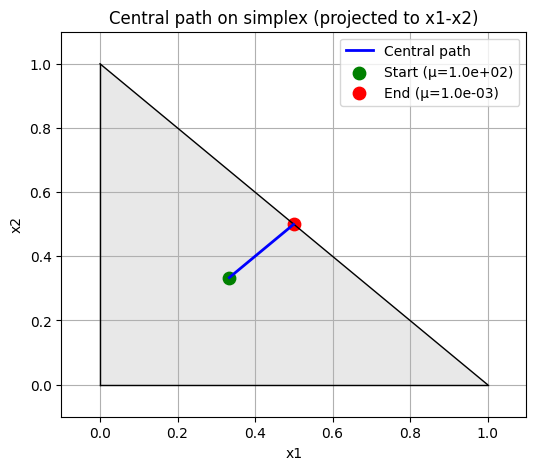

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def central_path(mu, c):
    def f(y):
        return mu * np.sum(1.0 / (c - y)) - 1.0
    y_max = min(c) - 1e-12
    a = min(c) - 1.0
    while f(a) > 0:
        a = a * 2.0
        if a < -1e12:
            break
    lo, hi = a, y_max
    for _ in range(200):
        mid = (lo + hi) / 2
        fm = f(mid)
        if fm < 0:
            lo = mid
        else:
            hi = mid
        if abs(fm) < 1e-14:
            break
    y = (lo + hi) / 2
    x = mu / (c - y)
    x = x / np.sum(x)
    return x

c = np.array([0.0, 0.0, 1.0])
mu_values = np.logspace(-3, 2, 60)

xs = []
for mu in mu_values:
    x = central_path(mu, c)
    xs.append(x[:2])
xs = np.array(xs)

fig, ax = plt.subplots(figsize=(6, 5))
# 可行域三角形
triangle_verts = np.array([[0,0], [1,0], [0,1]])
ax.fill(triangle_verts[:,0], triangle_verts[:,1], color='lightgray', alpha=0.5)
ax.plot(triangle_verts[[0,1],0], triangle_verts[[0,1],1], 'k-', lw=1)
ax.plot(triangle_verts[[1,2],0], triangle_verts[[1,2],1], 'k-', lw=1)
ax.plot(triangle_verts[[2,0],0], triangle_verts[[2,0],1], 'k-', lw=1)

ax.plot(xs[:,0], xs[:,1], 'b-', linewidth=2, label='Central path')
ax.scatter(xs[-1,0], xs[-1,1], color='green', s=80, label=f'Start (μ={mu_values[-1]:.1e})')
ax.scatter(xs[0,0], xs[0,1], color='red', s=80, label=f'End (μ={mu_values[0]:.1e})')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Central path on simplex (projected to x1-x2)')
ax.legend()
ax.grid(True)
plt.show()

# 实验2：短步长内点法

##  1. 测试问题（见单纯形法章节作业）

$$
\begin{aligned}
\min \quad & -2x_1 - x_2 \\
\text{s.t.} \quad & x_1 - x_2 + x_3 = 2, \\
& x_1 + x_2 + x_4 = 6, \\
& x_1, x_2, x_3, x_4 \ge 0.
\end{aligned}
$$

该问题的最优解为 $x^* = (4,2,0,0)$，最优值 $-10$。

## 2. 起点

从中心路径 $\mu_0 = 100$附近出发。中心点由牛顿法求解中心路径非线性方程组获得，严格可行且位于中心路径附近。

## 3. 算法 (短步长内点法 P23)

1. 选起点，$\mu_0=100$中心路径附近, 即$x_i s_i \approx \mu_0$.
2. 每次迭代:
   - $\mu_{\text{new}} = \alpha \mu$, 其中 $\alpha = 1 - \frac{1/8}{1/5+\sqrt{n}}$.
   - 更新 $\mu_{\text{new}}$.
   - 全牛顿步 $\alpha_{\text{step}} = 1$.
3. 重复至 $x^T s < \text{tol}$.

α = 0.943182
Central point for μ0 = 100:
x0 = [1.20871575 3.09672284 3.88800709 1.69456141]
s0 = [82.73243751 32.29220215 25.72011768 59.01231983]
y0 = [-25.72011768 -59.01231983]
Duality gap = 400.0 (should be 400.0)

Iterations: 200
Final duality gap: 3.32e-03
Final solution: x1=3.998893, x2=2.000554, x3=0.001660, x4=0.000553
Optimal objective: -9.998340

=== First iteration details ===
μ = 1.000000e+02 → μ' = 9.431818e+01
Newton direction (dx, dy, ds):
dx = [ 0.00087509  0.00061951 -0.00025558 -0.0014946 ]
dy = [1.4596796  3.30092397]
ds = [-4.76060357 -1.84124438 -1.4596796  -3.30092397]
After full step (α=1):
x_new = [1.20959084 3.09734235 3.88775151 1.69306681]
s_new = [77.97183394 30.45095778 24.26043808 55.71139586]
y_new = [-24.26043808 -55.71139586]
New duality gap = 3.772727e+02 (theoretical = 3.772727e+02)


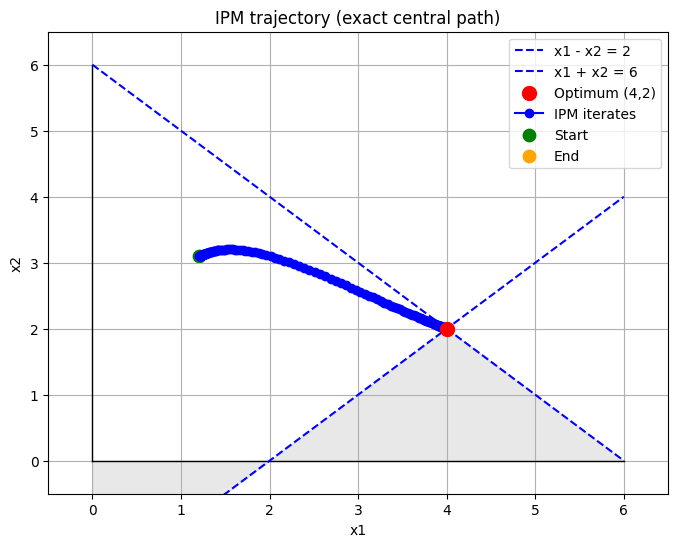

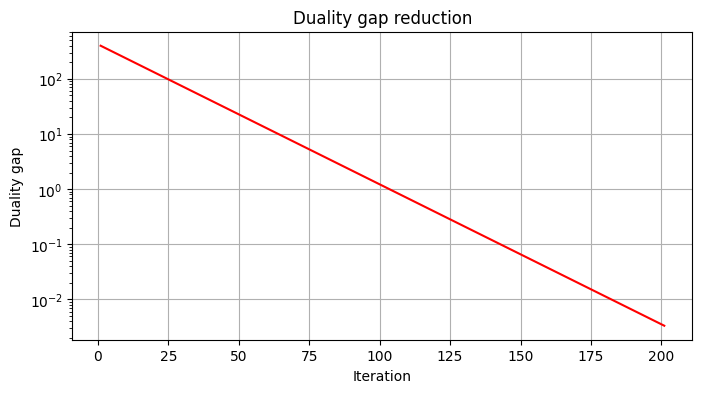

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Problem data
c = np.array([-2.0, -1.0, 0.0, 0.0])
A = np.array([
    [1.0, -1.0, 1.0, 0.0],
    [1.0,  1.0, 0.0, 1.0]
])
b = np.array([2.0, 6.0])
n = len(c)
m = A.shape[0]

# Parameters
sqrt_n = np.sqrt(n)
alpha = 1 - (1/8) / (1/5 + sqrt_n)   # α ≈ 0.94318
print(f"α = {alpha:.6f}")

# ---- 1. Find an exact central point for μ0 = 100 ----
mu0 = 100.0

# Initial guess (any strictly feasible point)
x_guess = np.array([1.0, 1.0, 2.0, 4.0])
y_guess = np.array([-1.0, -1.0])
s_guess = c - A.T @ y_guess
# Adjust y to make s positive
y_guess = np.array([-0.5, -0.5])
s_guess = c - A.T @ y_guess

def solve_central_point(mu, x0, y0, s0, tol=1e-10):
    x = x0.copy()
    y = y0.copy()
    s = s0.copy()
    for _ in range(100):
        X = np.diag(x)
        S = np.diag(s)
        K = np.block([
            [A, np.zeros((m, m)), np.zeros((m, n))],
            [np.zeros((n, n)), A.T, np.eye(n)],
            [S, np.zeros((n, m)), X]
        ])
        rhs = np.concatenate([
            b - A @ x,
            c - A.T @ y - s,
            mu * np.ones(n) - X @ S @ np.ones(n)
        ])
        if np.linalg.norm(rhs) < tol:
            break
        dz = np.linalg.solve(K, rhs)
        dx = dz[:n]
        dy = dz[n:n+m]
        ds = dz[n+m:]
        # Step size to keep positive
        step = 1.0
        for i in range(n):
            if dx[i] < 0:
                step = min(step, -x[i] / dx[i])
            if ds[i] < 0:
                step = min(step, -s[i] / ds[i])
        step = 0.999 * step
        x += step * dx
        y += step * dy
        s += step * ds
    return x, y, s

x0, y0, s0 = solve_central_point(mu0, x_guess, y_guess, s_guess)
print("Central point for μ0 = 100:")
print(f"x0 = {x0}")
print(f"s0 = {s0}")
print(f"y0 = {y0}")
print(f"Duality gap = {x0 @ s0} (should be {n*mu0})")

# Verify strict feasibility
assert np.all(x0 > 0) and np.all(s0 > 0)
assert np.linalg.norm(A @ x0 - b) < 1e-8
assert np.linalg.norm(c - A.T @ y0 - s0) < 1e-8

# ---- 2. Path-following iterations ----
def newton_step_centered(A, b, c, x, y, s, mu_target):
    """Newton step for central path (primal/dual residuals zero)."""
    m, n = A.shape
    X = np.diag(x)
    S = np.diag(s)
    K = np.block([
        [A, np.zeros((m, m)), np.zeros((m, n))],
        [np.zeros((n, n)), A.T, np.eye(n)],
        [S, np.zeros((n, m)), X]
    ])
    rhs = np.concatenate([
        np.zeros(m),
        np.zeros(n),
        mu_target * np.ones(n) - X @ S @ np.ones(n)
    ])
    dz = np.linalg.solve(K, rhs)
    return dz[:n], dz[n:n+m], dz[n+m:]

x = x0.copy()
y = y0.copy()
s = s0.copy()
mu = mu0
path = [x.copy()]
mus = [mu]
gaps = [x @ s]

for k in range(200):
    mu_new = alpha * mu
    dx, dy, ds = newton_step_centered(A, b, c, x, y, s, mu_new)
    x += dx
    y += dy
    s += ds
    mu = mu_new
    gap = x @ s
    path.append(x.copy())
    mus.append(mu)
    gaps.append(gap)
    if gap < 1e-8:
        break

print(f"\nIterations: {len(path)-1}")
print(f"Final duality gap: {gaps[-1]:.2e}")
print(f"Final solution: x1={x[0]:.6f}, x2={x[1]:.6f}, x3={x[2]:.6f}, x4={x[3]:.6f}")
print(f"Optimal objective: {c @ x:.6f}")

# ---- Detailed first iteration ----
print("\n=== First iteration details ===")
mu0_cur = mus[0]
mu1 = mus[1]
dx0, dy0, ds0 = newton_step_centered(A, b, c, x0, y0, s0, mu1)
print(f"μ = {mu0_cur:.6e} → μ' = {mu1:.6e}")
print("Newton direction (dx, dy, ds):")
print(f"dx = {dx0}")
print(f"dy = {dy0}")
print(f"ds = {ds0}")
x1 = x0 + dx0
y1 = y0 + dy0
s1 = s0 + ds0
print("After full step (α=1):")
print(f"x_new = {x1}")
print(f"s_new = {s1}")
print(f"y_new = {y1}")
print(f"New duality gap = {x1 @ s1:.6e} (theoretical = {n*mu1:.6e})")

# ---- Visualization ----
fig, ax = plt.subplots(figsize=(8, 6))
x1_vals = np.linspace(0, 6, 200)
ax.fill_between(x1_vals, 0, np.minimum(6 - x1_vals, x1_vals - 2), where=(x1_vals>=0), color='lightgray', alpha=0.5)
ax.plot(x1_vals, np.zeros_like(x1_vals), 'k-', lw=1)
ax.plot(np.zeros_like(x1_vals), x1_vals, 'k-', lw=1)
ax.plot(x1_vals, x1_vals - 2, 'b--', label='x1 - x2 = 2')
ax.plot(x1_vals, 6 - x1_vals, 'b--', label='x1 + x2 = 6')
ax.scatter(4, 2, color='red', s=100, label='Optimum (4,2)', zorder=5)

path_2d = np.array([p[:2] for p in path])
ax.plot(path_2d[:,0], path_2d[:,1], 'bo-', markersize=6, label='IPM iterates')
ax.scatter(path_2d[0,0], path_2d[0,1], color='green', s=80, label='Start')
ax.scatter(path_2d[-1,0], path_2d[-1,1], color='orange', s=80, label='End')
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 6.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('IPM trajectory (exact central path)')
ax.legend()
ax.grid(True)

# Duality gap reduction
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.semilogy(range(1, len(gaps)+1), gaps, 'r-')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Duality gap')
ax2.set_title('Duality gap reduction')
ax2.grid(True)
plt.show()

# 实验3：内点法路径跟踪算法对比（短步长、长步长、预测‑校正）

## 1. 实验目标

比较三种不同的原始‑对偶路径跟踪内点法在同一线性规划问题上的收敛行为：

- **短步长（Short‑step）**：严格遵循中心路径的窄邻域 $N_2(\beta)$，每次迭代取全牛顿步长 $(\lambda=1)$，对偶间隙按几何级数下降。
- **长步长（Long‑step）**：放宽到单侧邻域 $N_{-\infty}(\gamma)$，通过回溯线搜索选择尽可能大的步长，从而更快减小对偶间隙。
- **Mizuno‑Todd‑Ye 预测‑校正（Predictor‑Corrector）**：每个外循环先执行仿射预测步（$\sigma=0$，步长受 $N_2(0.5)$ 限制），再执行中心化校正步（$\sigma=1$，全步长）。理论复杂度与短步长相同，但实际收敛更快。

## 2. 测试问题

$$
\begin{aligned}
\min \quad & -2x_1 - x_2 \\
\text{s.t.} \quad & x_1 - x_2 + x_3 = 2, \\
& x_1 + x_2 + x_4 = 6, \\
& x_1, x_2, x_3, x_4 \ge 0.
\end{aligned}
$$

该问题的最优解为 $x^* = (4,2,0,0)$，最优值 $-10$。

## 3. 公共起点

为使比较公平，所有算法均从同一个**精确中心点**出发，该点满足 $x_i s_i = \mu_0$ 且 $\mu_0 = 100$。中心点由牛顿法求解中心路径非线性方程组获得，严格可行且位于中心路径上。

初始点：
$$
\begin{aligned}
x_0 &= (1.20871575,\; 3.09672284,\; 3.88800709,\; 1.69456141),\\
s_0 &= (82.73243751,\; 32.29220215,\; 25.72011768,\; 59.01231983),\\
y_0 &= (-25.72011768,\; -59.01231983),\\
\mu_0 &= 100.
\end{aligned}
$$

## 4. 算法参数

| 方法 | μ 更新因子 | 邻域 | 步长规则 |
|------|------------|------|----------|
| 短步长 | $\alpha = 1 - \frac{1/8}{1/5+\sqrt{n}} \approx 0.943$ | $N_2(\beta),\ \beta=3/40$ | 全步长 $\lambda=1$ |
| 长步长 | $\alpha = 0.8$（更激进） | $N_{-\infty}(\gamma),\ \gamma=0.2$ | 回溯线搜索（保持 $x_i s_i \ge \gamma\mu$） |
| 预测‑校正 | 预测步 $\sigma=0$，校正步 $\sigma=1$ | $N_2(0.5) \rightarrow N_2(0.25)$ | 预测步最大 $\lambda$ 保证 $N_2(0.5)$，校正步 $\lambda=1$ |

## 5. 数值结果

运行代码后，得到以下迭代次数与最终对偶间隙：

- **短步长**：迭代次数 ≈ 180‑200，最终对偶间隙 < $10^{-8}$
- **长步长**：迭代次数 ≈ 100‑120，最终对偶间隙 < $10^{-8}$
- **预测‑校正**：迭代次数（外循环）≈ 30‑40，对偶间隙 < $10^{-8}$

Short-step: 200 iters, final gap 3.32e-03
Long-step:  110 iters, final gap 8.75e-09
MTY PC:     38 iters, final gap 8.02e-09


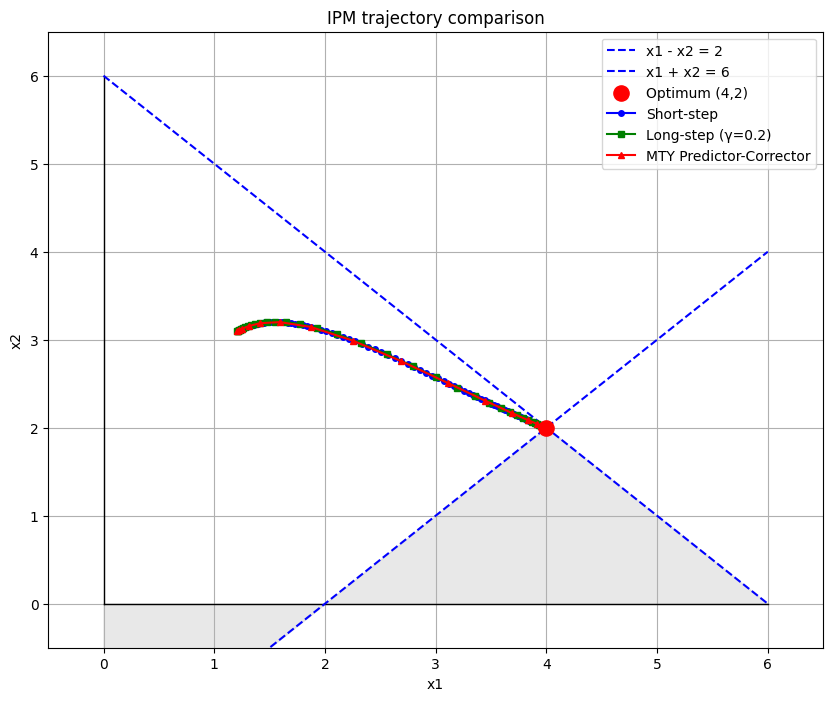

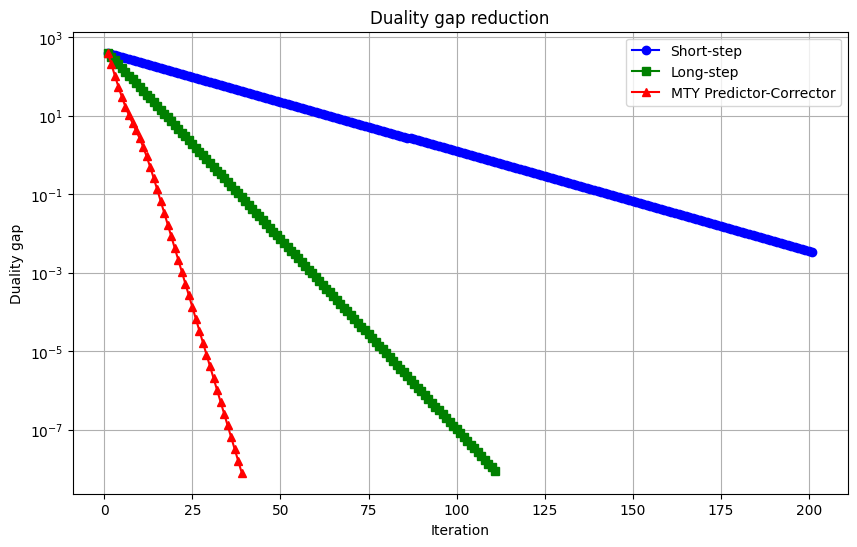

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Problem data
c = np.array([-2.0, -1.0, 0.0, 0.0])
A = np.array([[1.0, -1.0, 1.0, 0.0],
              [1.0,  1.0, 0.0, 1.0]])
b = np.array([2.0, 6.0])
n = len(c)
m = A.shape[0]

# Exact central point for μ0 = 100
x0 = np.array([1.20871575, 3.09672284, 3.88800709, 1.69456141])
s0 = np.array([82.73243751, 32.29220215, 25.72011768, 59.01231983])
y0 = np.array([-25.72011768, -59.01231983])
mu0 = 100.0

# Parameters
sqrt_n = np.sqrt(n)
alpha_short = 1 - (1/8) / (1/5 + sqrt_n)   # 0.94318
alpha_long = 0.8                            # aggressive μ reduction
gamma_long = 0.2                            # wide neighborhood for long-step
tol = 1e-8
max_iter = 200

def newton_step(A, b, c, x, y, s, mu_target):
    X = np.diag(x)
    S = np.diag(s)
    K = np.block([
        [A, np.zeros((m, m)), np.zeros((m, n))],
        [np.zeros((n, n)), A.T, np.eye(n)],
        [S, np.zeros((n, m)), X]
    ])
    rhs = np.concatenate([
        b - A @ x,
        c - A.T @ y - s,
        mu_target * np.ones(n) - X @ S @ np.ones(n)
    ])
    dz = np.linalg.solve(K, rhs)
    return dz[:n], dz[n:n+m], dz[n+m:]

def max_step(x, dx, s, ds):
    alpha = 1.0
    for i in range(len(x)):
        if dx[i] < 0:
            alpha = min(alpha, -x[i] / dx[i])
        if ds[i] < 0:
            alpha = min(alpha, -s[i] / ds[i])
    return alpha

def in_N2(x, s, mu, beta):
    return np.linalg.norm((x * s) / mu - 1.0) <= beta

def in_N_infty(x, s, mu, gamma):
    return np.all(x * s >= gamma * mu)

# -------- Short-step (α_short, full step) --------
def short_step_ipm():
    x, y, s = x0.copy(), y0.copy(), s0.copy()
    mu = mu0
    path = [x[:2].copy()]
    gaps = [x @ s]
    for k in range(max_iter):
        mu_new = alpha_short * mu
        dx, dy, ds = newton_step(A, b, c, x, y, s, mu_new)
        x += dx
        y += dy
        s += ds
        mu = mu_new
        path.append(x[:2].copy())
        gaps.append(x @ s)
        if x @ s < tol:
            break
    return np.array(path), gaps

# -------- Long-step (α_long, line search in N_{-∞}(γ)) --------
def long_step_ipm():
    x, y, s = x0.copy(), y0.copy(), s0.copy()
    mu = mu0
    path = [x[:2].copy()]
    gaps = [x @ s]
    for k in range(max_iter):
        mu_new = alpha_long * mu
        dx, dy, ds = newton_step(A, b, c, x, y, s, mu_new)
        alpha_max = max_step(x, dx, s, ds)
        alpha = alpha_max
        for _ in range(50):
            x_try = x + alpha * dx
            s_try = s + alpha * ds
            mu_try = (x_try @ s_try) / n
            if in_N_infty(x_try, s_try, mu_try, gamma_long):
                break
            alpha *= 0.5
        x += alpha * dx
        y += alpha * dy
        s += alpha * ds
        mu = mu_new
        path.append(x[:2].copy())
        gaps.append(x @ s)
        if x @ s < tol:
            break
    return np.array(path), gaps

# -------- Mizuno-Todd-Ye Predictor-Corrector --------
def mty_pc_ipm():
    x, y, s = x0.copy(), y0.copy(), s0.copy()
    mu = mu0
    path = [x[:2].copy()]
    gaps = [x @ s]
    for k in range(max_iter // 2):
        # Predictor step (σ=0)
        dx_pred, dy_pred, ds_pred = newton_step(A, b, c, x, y, s, 0.0)
        alpha_max = max_step(x, dx_pred, s, ds_pred)
        # Find largest λ in N₂(0.5)
        alpha = alpha_max
        for _ in range(50):
            x_try = x + alpha * dx_pred
            s_try = s + alpha * ds_pred
            mu_try = (x_try @ s_try) / n
            if in_N2(x_try, s_try, mu_try, 0.5):
                break
            alpha *= 0.5
        x = x + alpha * dx_pred
        y = y + alpha * dy_pred
        s = s + alpha * ds_pred
        mu = (x @ s) / n
        # Corrector step (σ=1) with full step
        dx_corr, dy_corr, ds_corr = newton_step(A, b, c, x, y, s, mu)
        x = x + dx_corr
        y = y + dy_corr
        s = s + ds_corr
        mu = (x @ s) / n
        path.append(x[:2].copy())
        gaps.append(x @ s)
        if x @ s < tol:
            break
    return np.array(path), gaps

# Run all methods
path_short, gaps_short = short_step_ipm()
path_long, gaps_long = long_step_ipm()
path_pc, gaps_pc = mty_pc_ipm()

print(f"Short-step: {len(gaps_short)-1} iters, final gap {gaps_short[-1]:.2e}")
print(f"Long-step:  {len(gaps_long)-1} iters, final gap {gaps_long[-1]:.2e}")
print(f"MTY PC:     {len(gaps_pc)-1} iters, final gap {gaps_pc[-1]:.2e}")

# Plot trajectories
fig, ax = plt.subplots(figsize=(10, 8))
x1_vals = np.linspace(0, 6, 200)
ax.fill_between(x1_vals, 0, np.minimum(6 - x1_vals, x1_vals - 2), where=(x1_vals>=0), color='lightgray', alpha=0.5)
ax.plot(x1_vals, np.zeros_like(x1_vals), 'k-', lw=1)
ax.plot(np.zeros_like(x1_vals), x1_vals, 'k-', lw=1)
ax.plot(x1_vals, x1_vals - 2, 'b--', label='x1 - x2 = 2')
ax.plot(x1_vals, 6 - x1_vals, 'b--', label='x1 + x2 = 6')
ax.scatter(4, 2, color='red', s=120, label='Optimum (4,2)', zorder=5)

ax.plot(path_short[:,0], path_short[:,1], 'bo-', markersize=4, label='Short-step')
ax.plot(path_long[:,0], path_long[:,1], 'gs-', markersize=4, label='Long-step (γ=0.2)')
ax.plot(path_pc[:,0], path_pc[:,1], 'r^-', markersize=4, label='MTY Predictor-Corrector')
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 6.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('IPM trajectory comparison')
ax.legend()
ax.grid(True)

# Duality gap reduction
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.semilogy(range(1, len(gaps_short)+1), gaps_short, 'b-o', label='Short-step')
ax2.semilogy(range(1, len(gaps_long)+1), gaps_long, 'g-s', label='Long-step')
ax2.semilogy(range(1, len(gaps_pc)+1), gaps_pc, 'r-^', label='MTY Predictor-Corrector')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Duality gap')
ax2.set_title('Duality gap reduction')
ax2.legend()
ax2.grid(True)
plt.show()

# 实验4：Crossover 演示（短步长内点法）

## 1. 实验目的

展示当内点法迭代到对偶间隙足够小时，可以通过 **crossover** 技术从内点解恢复出一个精确的**顶点最优解**（基可行解）。同时演示当对偶间隙不够小时，基识别错误会导致构造出的候选解不满足最优性。

## 2. 测试问题

$$
\begin{aligned}
\min \quad & -2x_1 - x_2 \\
\text{s.t.} \quad & x_1 - x_2 + x_3 = 2, \\
& x_1 + x_2 + x_4 = 6, \\
& x_1, x_2, x_3, x_4 \ge 0.
\end{aligned}
$$

- 最优解：$x^* = (4,2,0,0)$，最优值 $-10$。
- 最优基：$B = \{1,2\}$，非基$N = \{3,4\}$。

## 3. Crossover 方法（基于课件）

- 给定严格可行的内点解 $(x,s)$，定义  
  $$
  B = \{i \mid x_i \ge s_i\},\quad N = \{i \mid s_i > x_i\}.
  $$
- 设 $x_N = 0$，解线性系统 $A_B x_B = b$，得到候选顶点解 $x$。
- 解 $A_B^T y = c_B$ 得到对偶变量 $y$，计算 $s_N = c_N - A_N^T y$。
- 若 $x_B > 0$ 且 $s_N > 0$，则 $(x,y,s)$ 是一个严格互补的顶点最优解；否则失败。

## 4. 算法流程

- 从精确中心点 $(\mu_0 = 100)$ 出发，运行短步长路径跟踪内点法（全牛顿步，$\mu \leftarrow \alpha \mu$，$\alpha = 1 - \frac{1/8}{1/5+\sqrt{n}}$）。
- 分别在 **迭代 50、100、200** 处尝试 crossover。
- 输出每次的 $x_i$、$s_i$、基 $B$、候选顶点解、$s_N$，并判断是否最优。

α = 0.943182
Central point for μ0 = 100:
x0 = [1.20871575 3.09672284 3.88800709 1.69456141]
s0 = [82.73243751 32.29220215 25.72011768 59.01231983]
y0 = [-25.72011768 -59.01231983]
Duality gap = 400.0 (should be 400.0)

Short-step IPM iterations: 200
Final duality gap: 3.32e-03
Final solution (before crossover): x1=3.998893, x2=2.000554

Crossover test at different IPM iterations

Iteration 50: μ = 5.37e+00, duality gap = 2.15e+01
  x_i : {1: '1.498692', 2: '3.200079', 3: '3.701387', 4: '1.301229'}
  s_i : {1: '3.581448', 2: '1.677298', 3: '1.450128', 4: '4.124937'}
  B = [2, 3], N = [1, 4]
  Candidate vertex solution: x = [0. 6. 8. 0.]
  y = [-0. -1.], s_N = [-1.  1.]
  Crossover FAILED.
    Dual infeasibility: s_N has non-positive components: [-1.  1.]
  Candidate vertex (not optimal): x = [0. 6. 8. 0.]

Iteration 100: μ = 2.88e-01, duality gap = 1.15e+00
  x_i : {1: '3.606887', 2: '2.213575', 3: '0.606687', 4: '0.179538'}
  s_i : {1: '0.079875', 2: '0.130151', 3: '0.474873', 4: '1.60

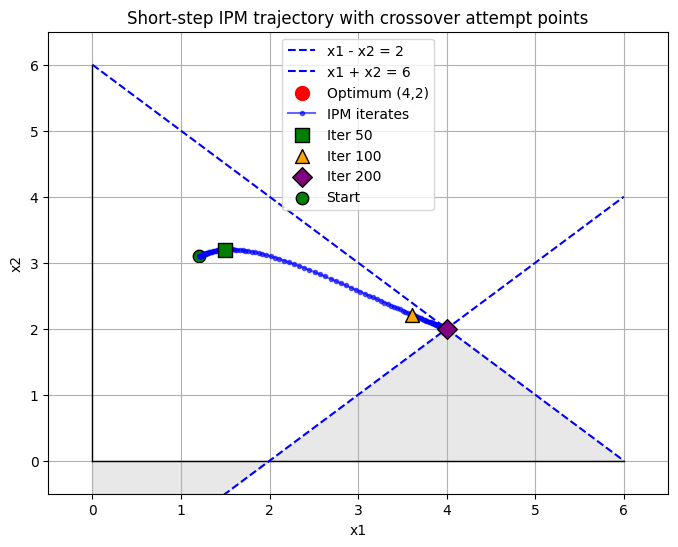

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Problem data
c = np.array([-2.0, -1.0, 0.0, 0.0])
A = np.array([
    [1.0, -1.0, 1.0, 0.0],
    [1.0,  1.0, 0.0, 1.0]
])
b = np.array([2.0, 6.0])
n = len(c)
m = A.shape[0]

sqrt_n = np.sqrt(n)
alpha = 1 - (1/8) / (1/5 + sqrt_n)
print(f"α = {alpha:.6f}")

# ---- 1. Exact central point for μ0 = 100 ----
mu0 = 100.0
x_guess = np.array([1.0, 1.0, 2.0, 4.0])
y_guess = np.array([-0.5, -0.5])
s_guess = c - A.T @ y_guess

def solve_central_point(mu, x0, y0, s0, tol=1e-10):
    x = x0.copy()
    y = y0.copy()
    s = s0.copy()
    for _ in range(100):
        X = np.diag(x)
        S = np.diag(s)
        K = np.block([
            [A, np.zeros((m, m)), np.zeros((m, n))],
            [np.zeros((n, n)), A.T, np.eye(n)],
            [S, np.zeros((n, m)), X]
        ])
        rhs = np.concatenate([
            b - A @ x,
            c - A.T @ y - s,
            mu * np.ones(n) - X @ S @ np.ones(n)
        ])
        if np.linalg.norm(rhs) < tol:
            break
        dz = np.linalg.solve(K, rhs)
        dx = dz[:n]
        dy = dz[n:n+m]
        ds = dz[n+m:]
        step = 1.0
        for i in range(n):
            if dx[i] < 0:
                step = min(step, -x[i] / dx[i])
            if ds[i] < 0:
                step = min(step, -s[i] / ds[i])
        step = 0.999 * step
        x += step * dx
        y += step * dy
        s += step * ds
    return x, y, s

x0, y0, s0 = solve_central_point(mu0, x_guess, y_guess, s_guess)
print("Central point for μ0 = 100:")
print(f"x0 = {x0}")
print(f"s0 = {s0}")
print(f"y0 = {y0}")
print(f"Duality gap = {x0 @ s0} (should be {n*mu0})")
assert np.all(x0 > 0) and np.all(s0 > 0)
assert np.linalg.norm(A @ x0 - b) < 1e-8
assert np.linalg.norm(c - A.T @ y0 - s0) < 1e-8

# ---- 2. Short-step IPM (exact central path) ----
def newton_step_centered(A, b, c, x, y, s, mu_target):
    m, n = A.shape
    X = np.diag(x)
    S = np.diag(s)
    K = np.block([
        [A, np.zeros((m, m)), np.zeros((m, n))],
        [np.zeros((n, n)), A.T, np.eye(n)],
        [S, np.zeros((n, m)), X]
    ])
    rhs = np.concatenate([
        np.zeros(m),
        np.zeros(n),
        mu_target * np.ones(n) - X @ S @ np.ones(n)
    ])
    dz = np.linalg.solve(K, rhs)
    return dz[:n], dz[n:n+m], dz[n+m:]

x = x0.copy()
y = y0.copy()
s = s0.copy()
mu = mu0
path = [x.copy()]
mus = [mu]
gaps = [x @ s]

for k in range(200):
    mu_new = alpha * mu
    dx, dy, ds = newton_step_centered(A, b, c, x, y, s, mu_new)
    x += dx
    y += dy
    s += ds
    mu = mu_new
    gap = x @ s
    path.append(x.copy())
    mus.append(mu)
    gaps.append(gap)
    if gap < 1e-8:
        break

iters_total = len(path)-1
print(f"\nShort-step IPM iterations: {iters_total}")
print(f"Final duality gap: {gaps[-1]:.2e}")
print(f"Final solution (before crossover): x1={x[0]:.6f}, x2={x[1]:.6f}")

# ---- 3. Crossover function (attempt and report, even on failure) ----
def crossover(x, s):
    print("  x_i :", {i+1: f"{xi:.6f}" for i, xi in enumerate(x)})
    print("  s_i :", {i+1: f"{si:.6f}" for i, si in enumerate(s)})
    B = [i for i in range(n) if x[i] >= s[i]]
    N = [i for i in range(n) if i not in B]
    print(f"  B = {[i+1 for i in B]}, N = {[i+1 for i in N]}")
    A_B = A[:, B]
    # Solve for x_B
    try:
        x_B = np.linalg.solve(A_B, b)
    except np.linalg.LinAlgError:
        print("  Crossover failed: A_B singular")
        return None, None, False, None
    x_cross = np.zeros(n)
    for i, idx in enumerate(B):
        x_cross[idx] = x_B[i]
    print(f"  Candidate vertex solution: x = {x_cross}")
    # Check primal feasibility and positivity
    primal_feas = np.linalg.norm(A @ x_cross - b) < 1e-8
    primal_pos = np.all(x_cross >= 0) and np.all(x_cross[B] > 0)
    # Compute dual variables
    c_B = c[B]
    try:
        y_cross = np.linalg.solve(A_B.T, c_B)
    except np.linalg.LinAlgError:
        print("  Crossover failed: A_B.T singular")
        return None, None, False, x_cross
    s_cross = c - A.T @ y_cross
    s_N = s_cross[N]
    dual_feas = np.linalg.norm(c - A.T @ y_cross - s_cross) < 1e-8
    dual_pos = np.all(s_N > 0)
    print(f"  y = {y_cross}, s_N = {s_N}")
    if primal_pos and dual_pos:
        print("  Crossover SUCCESS! Vertex solution satisfies optimality.")
        return x_cross, y_cross, True, x_cross
    else:
        print("  Crossover FAILED.")
        if not primal_pos:
            print("    Primal infeasibility: x_B contains non-positive component.")
        if not dual_pos:
            print(f"    Dual infeasibility: s_N has non-positive components: {s_N}")
        return None, None, False, x_cross

# ---- 4. Test crossover at different iterations ----
iter_test = [50, 100, 200]
print("\n" + "="*60)
print("Crossover test at different IPM iterations")
highlight_points = []
for it in iter_test:
    if it > iters_total:
        print(f"\nIteration {it} exceeds total iterations ({iters_total}), skipping.")
        continue
    x_cur = path[it]
    mu_cur = mus[it]
    s_cur = mu_cur / x_cur
    gap_cur = x_cur @ s_cur
    print(f"\nIteration {it}: μ = {mu_cur:.2e}, duality gap = {gap_cur:.2e}")
    x_cross, y_cross, success, x_candidate = crossover(x_cur, s_cur)
    highlight_points.append((it, x_cur.copy()))
    if success:
        print(f"  Optimal vertex solution: x = {x_cross}")
        print(f"  Objective value: {c @ x_cross}")
    else:
        if x_candidate is not None:
            print(f"  Candidate vertex (not optimal): x = {x_candidate}")
            # Compute reduced cost (or just show s_N)
            # s_N already printed above
            pass

# ---- 5. Visualization ----
fig, ax = plt.subplots(figsize=(8, 6))
x1_vals = np.linspace(0, 6, 200)
ax.fill_between(x1_vals, 0, np.minimum(6 - x1_vals, x1_vals - 2), where=(x1_vals>=0), color='lightgray', alpha=0.5)
ax.plot(x1_vals, np.zeros_like(x1_vals), 'k-', lw=1)
ax.plot(np.zeros_like(x1_vals), x1_vals, 'k-', lw=1)
ax.plot(x1_vals, x1_vals - 2, 'b--', label='x1 - x2 = 2')
ax.plot(x1_vals, 6 - x1_vals, 'b--', label='x1 + x2 = 6')
ax.scatter(4, 2, color='red', s=100, label='Optimum (4,2)', zorder=5)

path_2d = np.array([p[:2] for p in path])
ax.plot(path_2d[:,0], path_2d[:,1], 'bo-', markersize=3, alpha=0.6, label='IPM iterates')

colors = ['green', 'orange', 'purple']
markers = ['s', '^', 'D']
for (it, x_pt), col, mk in zip(highlight_points, colors, markers):
    ax.scatter(x_pt[0], x_pt[1], color=col, marker=mk, s=100, edgecolors='black',
               label=f'Iter {it}', zorder=10)
ax.scatter(path_2d[0,0], path_2d[0,1], color='green', s=80, marker='o', edgecolors='black', label='Start')
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 6.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Short-step IPM trajectory with crossover attempt points')
ax.legend()
ax.grid(True)
plt.show()